In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from pandas.plotting import scatter_matrix
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

sns.set()

In [2]:
# California Housing Dataset
housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns=housing.feature_names)
data["MedHouseVal"] = housing.target

data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Quick data inspection
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


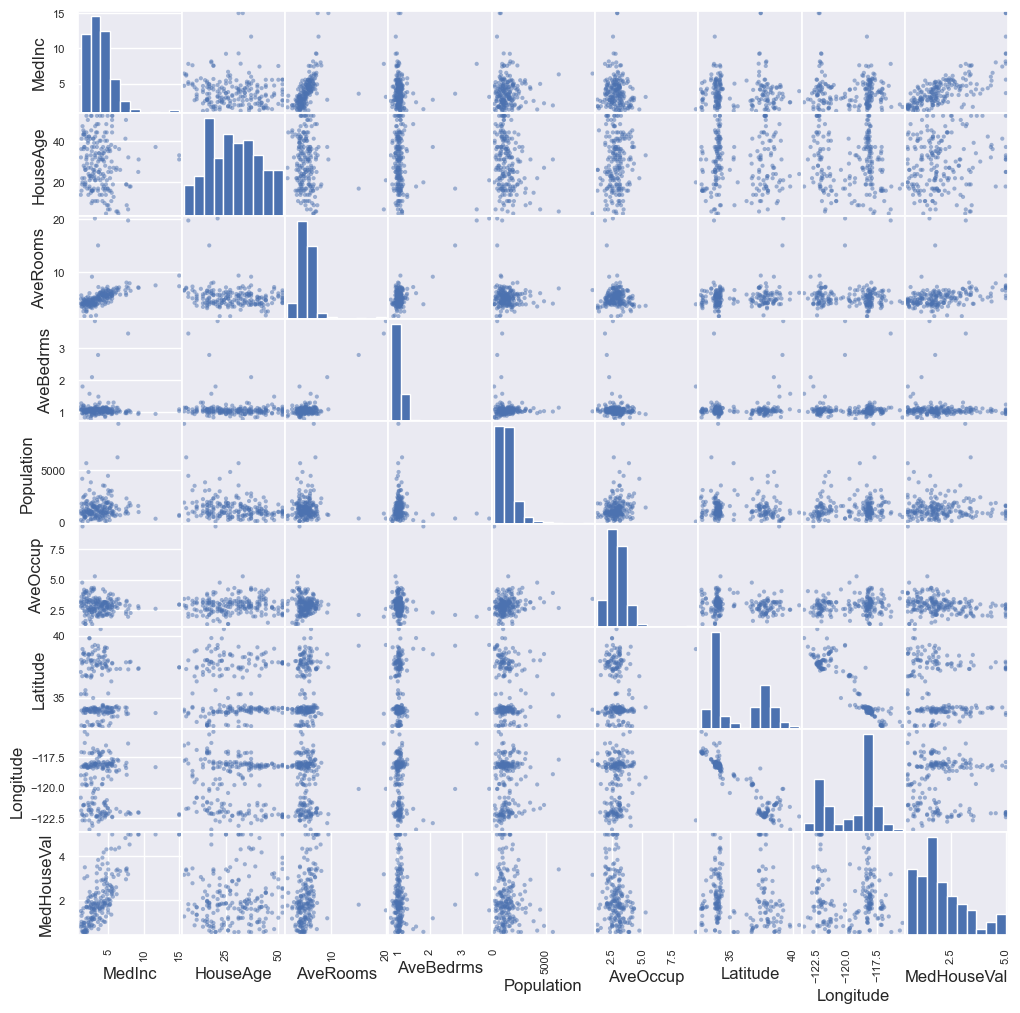

In [5]:
# scatter_matrix(data.sample(200)[["MedHouseVal","MedInc","AveRooms","HouseAge"]], figsize=(8,8))
scatter_matrix(data.sample(200), figsize=(12, 12))
plt.show()

In [6]:
# correlation matrix: Useful but can be hard to read
data.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


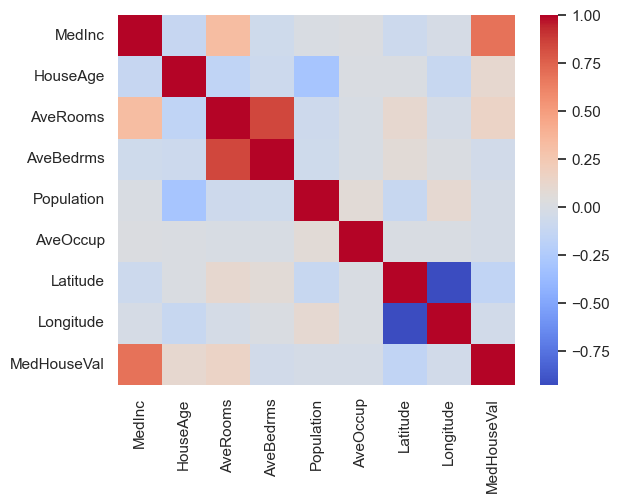

In [7]:
# better visualization of correlation matrix
sns.heatmap(data.corr(), annot=False, cmap="coolwarm")
plt.show()

# Notice that AveRooms and AveBedrms are highly correlated.
# Regression suffers from multicollinearity.
# This does not necessarily harm prediction accuracy, but it makes the interpretation of coefficients unreliable.
# The regression has difficulty determining which variable should get credit for explaining the target.

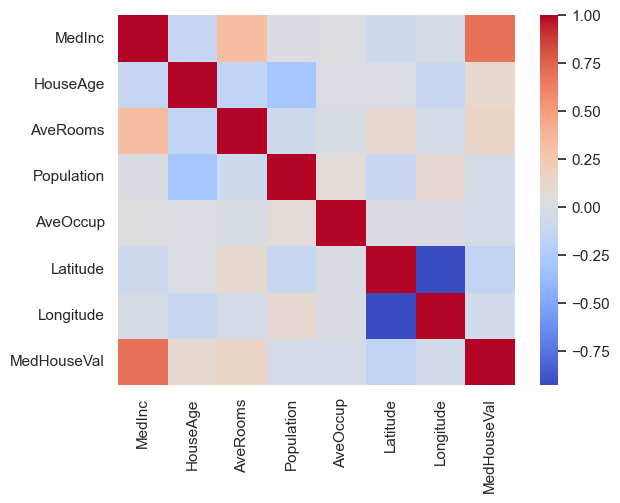

In [8]:
# Drop AveBedrms
data = data.drop(columns=["AveBedrms"])
sns.heatmap(data.corr(), annot=False, cmap="coolwarm")
plt.show()

In [9]:
# Prepare data for regression
X = data.drop("MedHouseVal", axis=1)
y = data["MedHouseVal"]

# Add intercept
X = sm.add_constant(X)

In [10]:
# Fit the regression model
model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     4352.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:06:54   Log-Likelihood:                -22883.
No. Observations:               20640   AIC:                         4.578e+04
Df Residuals:                   20632   BIC:                         4.585e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -39.0492      0.661    -59.103      0.0

In [11]:
# The coefficients are not on the same scale, so it's hard to compare their relative importance.
# This also makes the model unstable and sensitive to small changes in the data.
# This is indicated in statsmodels' notes as "Condition Number" which is very high.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.drop("MedHouseVal", axis=1))

X_scaled = pd.DataFrame(X_scaled, columns=data.columns[:-1])
X_scaled = sm.add_constant(X_scaled)

model_scaled = sm.OLS(y, X_scaled)
results_scaled = model_scaled.fit()
print(results_scaled.summary())

# NOTE: Now the model expects standardized features in the future.
# So if we want to make predictions, we need to standardize the features first before feeding them into the model.

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     4352.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:06:54   Log-Likelihood:                -22883.
No. Observations:               20640   AIC:                         4.578e+04
Df Residuals:                   20632   BIC:                         4.585e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0686      0.005    405.206      0.0

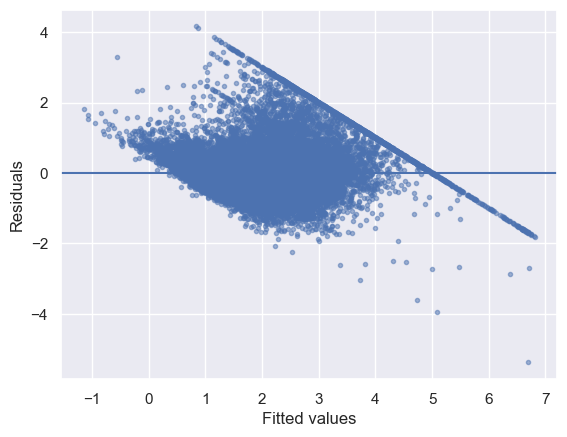

In [12]:
# Residual analysis
# Residuals should look randomly scattered around zero.
residuals = results.resid

plt.scatter(results.fittedvalues, residuals, marker=".", alpha=0.5)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

<Axes: >

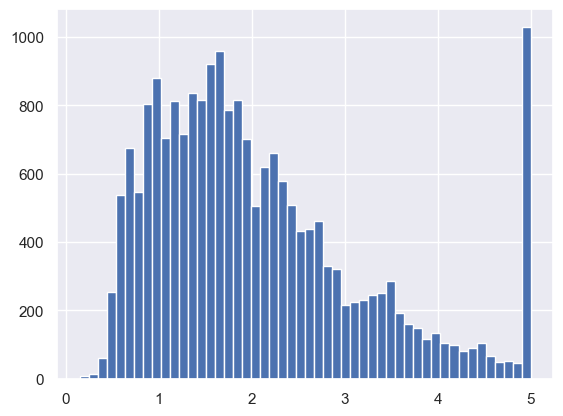

In [13]:
# What's that straight line in the residual plot?
# In the housing dataset, the target variable (MedHouseVal) is capped at 5 (i.e., $500,000).
# This creates a ceiling effect where many observations have the same maximum value,
# leading to a straight line in the residual plot at that value.

# Mathematically
# For all the points capped at 5, the residual is:
# residual = observed - predicted = 5 - predicted
# This is a straight line with slope -1.

data.MedHouseVal.hist(bins=50)

In [14]:
# Let's drop the capped values and retrain the model.
data_uncapped = data[data["MedHouseVal"] < 5]
X_uncapped = data_uncapped.drop("MedHouseVal", axis=1)
y_uncapped = data_uncapped["MedHouseVal"]
X_uncapped = sm.add_constant(X_uncapped)
model_uncapped = sm.OLS(y_uncapped, X_uncapped)
results_uncapped = model_uncapped.fit()
print(results_uncapped.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     3611.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:06:54   Log-Likelihood:                -19176.
No. Observations:               19648   AIC:                         3.837e+04
Df Residuals:                   19640   BIC:                         3.843e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -35.9911      0.594    -60.601      0.0

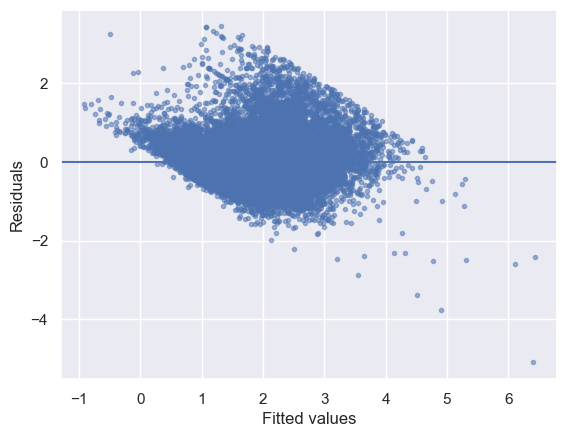

In [15]:
# Residual analysis
# Residuals should look randomly scattered around zero.
residuals_uncapped = results_uncapped.resid

plt.scatter(results_uncapped.fittedvalues, residuals_uncapped, marker=".", alpha=0.5)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

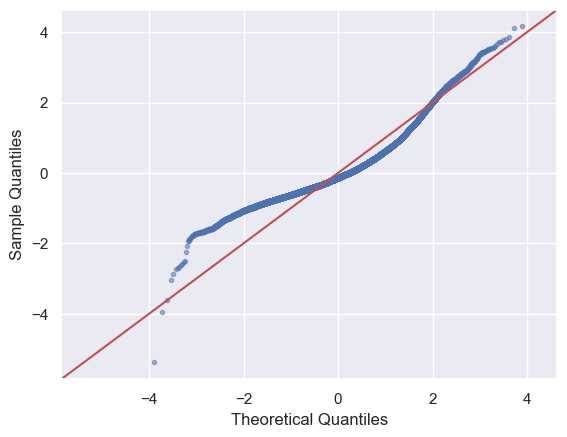

In [ ]:
sm.qqplot(residuals, line="45", marker=".", alpha=0.5)
plt.show()

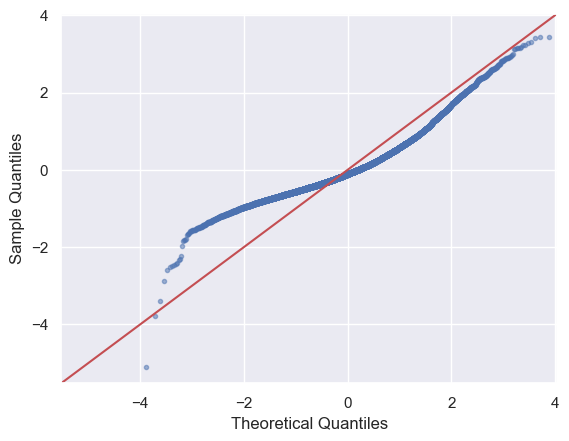

In [ ]:
sm.qqplot(residuals_uncapped, line="45", marker=".", alpha=0.5)
plt.show()